In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import yfinance as yf
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo

In [2]:
# Setting plot aesthetics
sns.set(style='darkgrid', context='talk', palette='Dark2')

# Defining the time frame for data collection
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=365 * 7)

# List of stock symbols for factor analysis
symbols = ['AAPL', 'MSFT', 'AMD', 'NVDA']

In [3]:
# Fetching adjusted close prices for the specified symbols
df = pd.DataFrame({symbol: yf.download(symbol, start_date, end_date)['Adj Close']
                   for symbol in symbols})

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [4]:
# Initializing FactorAnalyzer and fitting it to our data
fa = FactorAnalyzer(rotation=None, n_factors=df.shape[1])
fa.fit(df.dropna())

FactorAnalyzer(n_factors=4, rotation=None, rotation_kwargs={})

In [5]:
# Extracting communalities, eigenvalues, and factor loadings
communalities = fa.get_communalities()
eigenvalues, _ = fa.get_eigenvalues()
loadings = fa.loadings_

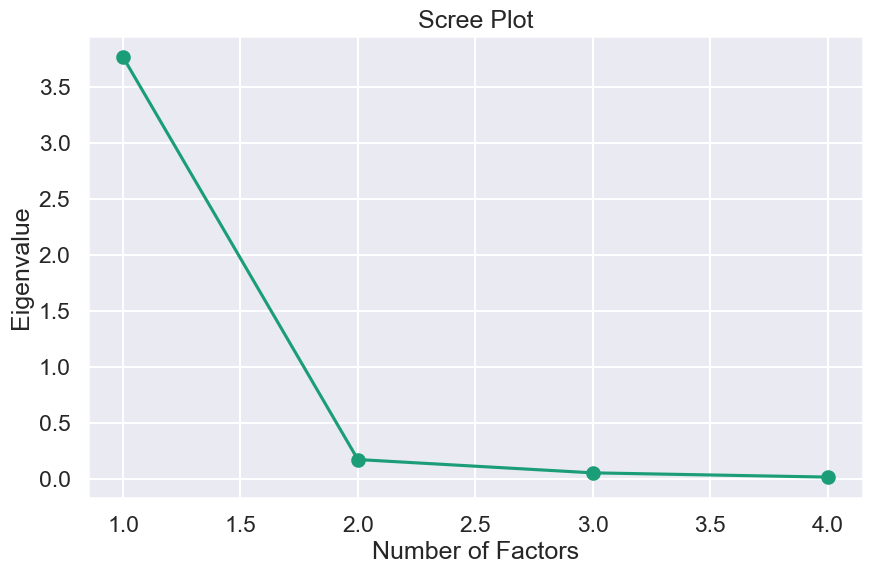

In [6]:
# Plotting the Scree plot to assess the number of factors
plt.figure(figsize=(10, 6))
plt.scatter(range(1, df.shape[1] + 1), eigenvalues)
plt.plot(range(1, df.shape[1] + 1), eigenvalues)
plt.title('Scree Plot')
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

In [7]:
# Bartlett's test of sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(df.dropna())
print('Bartlett sphericity test:\nChi-square value:', chi_square_value, '\nP-value:', p_value)

Bartlett sphericity test:
Chi-square value: 13522.745478885816 
P-value: 0.0


In [8]:
# Kaiser-Meyer-Olkin (KMO) test
kmo_all, kmo_model = calculate_kmo(df.dropna())
print('Kaiser-Meyer-Olkin (KMO) Test:\nOverall KMO:', kmo_all, '\nKMO per variable:', kmo_model)

Kaiser-Meyer-Olkin (KMO) Test:
Overall KMO: [0.82311707 0.71116682 0.86642019 0.92979412] 
KMO per variable: 0.8204727469331107


In [9]:
# Printing results
print("\nFactor Analysis Results:")
print("\nCommunalities:\n", communalities)
print("\nFactor Loadings:\n", loadings)


Factor Analysis Results:

Communalities:
 [0.98053557 0.99502493 0.96670548 0.83484216]

Factor Loadings:
 [[ 9.81852731e-01 -5.38309787e-02 -1.16631948e-01  0.00000000e+00]
 [ 9.97501674e-01 -3.34196897e-04 -3.90248512e-03  0.00000000e+00]
 [ 9.72998742e-01 -9.87738225e-02  1.01107147e-01  0.00000000e+00]
 [ 8.98173566e-01  1.66219833e-01  2.23019313e-02  0.00000000e+00]]
